In [1]:
import os
# Version for filename
ver = 'GRU'  # GRU or LSTM

date = "251128"
dl_folder = f"D:/Python_TK_3/datas/{date}_DL"

dl_number = "Vis_angle_multi_01"
#os.mkdir(f"{dl_folder}/model_{dl_number}")

In [2]:
# データのサンプリングレート
fs = 20  # サンプリング周波数
first_ex = 0
last_ex = 39
NumberOfDatas = last_ex - first_ex + 1        # number of experiments
start_stim = 20
stop_stim = 30
calc_start = 5
calc_end = 39
start_ave= 5
end_ave= 11
look_frame = 30   

In [3]:
import numpy as np

model_number = 3

input_train = np.load(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_train_features.npy")
trainY      = np.load(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_train_targets.npy")

input_valid = np.load(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_valid_features.npy", )
validY      = np.load(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_valid_targets.npy")

#input_test  = np.load(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_features.npy")
#testY       = np.load(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_targets.npy")

In [4]:
print(input_train.shape)
print(trainY.shape)

print(input_valid.shape)
print(validY.shape)

#print(input_test.shape)
#print(testY.shape)

(5650, 31, 23)
(5650,)
(1500, 31, 23)
(1500,)


In [5]:
from tensorflow.keras.models import Sequential, load_model

epoch_number = 5

model_file_path = f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_ver{ver}_epoch0{epoch_number}.h5"
model = load_model(model_file_path)

Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor
Instructions for updating:
If using Keras pass *_constraint arguments to layers.
Instructions for updating:
Use tf.where in 2.0, which has the same broadcast rule as np.where


In [6]:
# Calcurate accuracy
#model.evaluate(input_test,testY)
model.evaluate(input_valid, validY)

1500/1500 [==============================] - 1s 1000us/sample - loss: 0.5968 - acc: 0.6967


[0.5968192458152771, 0.69666666]

In [7]:
# Predict
train_pred = model.predict(input_train)
valid_pred = model.predict(input_valid)
#test_pred = model.predict(input_test)

In [8]:
# Label
train_target = trainY
valid_target = validY
#test_target = testY

In [9]:
#prediction_frames = 25 - look_frame
prediction_frames = 50
print(prediction_frames)

50


In [10]:
# 初期値
start_value = 0.0 + (look_frame/fs)

# 増加量
increment = 1/fs

# 繰り返し回数
count = prediction_frames

# リストを生成
t = [start_value + i * increment for i in range(count)]

In [11]:
np.save(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_truth_train.npy", train_target)
np.save(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_prediction_train.npy", train_pred)
np.save(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_truth_valid.npy", valid_target)
np.save(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_prediction_valid.npy", valid_pred)
#np.save(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_truth_test.npy", test_target)
#np.save(f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_prediction_test.npy", test_pred)

In [12]:
import numpy as np

fpr_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_train_fpr.npy"))
tpr_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_train_tpr.npy"))
AUC_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_train_auc.npy"))
opt_thr_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_train_threshold.npy"))

fpr_va = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_valid_fpr.npy"))
tpr_va = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_valid_tpr.npy"))
AUC_va = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_valid_auc.npy"))
opt_thr_va = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_valid_threshold.npy"))

#fpr_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_fpr.npy"))
#tpr_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_tpr.npy"))
#AUC_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_auc.npy"))
#opt_thr_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_threshold.npy"))

In [13]:
import tqdm
import numpy as np
import os

#epoch_number = 20

all_tr_fpr = []
all_tr_tpr = []
all_tr_AUC = []
all_tr_opt_thr = []

all_va_fpr = []
all_va_tpr = []
all_va_AUC = []
all_va_opt_thr = []

#all_te_fpr = []
#all_te_tpr = []
#all_te_AUC = []
#all_te_opt_thr = []
for n in tqdm.tqdm(range(5)):
    # 保存先ディレクトリを作成
    model_dir = os.path.join(os.path.join(dl_folder, f"model_{dl_number}"), f"model_{n}")

    fpr_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_train_fpr.npy"))
    tpr_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_train_tpr.npy"))
    AUC_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_train_auc.npy"))
    opt_thr_tr = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_train_threshold.npy"))
    all_tr_fpr.append(fpr_tr)
    all_tr_tpr.append(tpr_tr)
    all_tr_AUC.append(AUC_tr)
    all_tr_opt_thr.append(opt_thr_tr)

    fpr_va = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_valid_fpr.npy"))
    tpr_va = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_valid_tpr.npy"))
    AUC_va = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_valid_auc.npy"))
    opt_thr_va = np.load((f"{dl_folder}/model_{dl_number}/model_{n}/{date}_{dl_number}_valid_threshold.npy"))
    all_va_fpr.append(fpr_va)
    all_va_tpr.append(tpr_va)
    all_va_AUC.append(AUC_va)
    all_va_opt_thr.append(opt_thr_va)


    #fpr_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_fpr.npy"))
    #tpr_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_tpr.npy"))
    #AUC_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_auc.npy"))
    #opt_thr_te = np.load((f"{dl_folder}/model_{dl_number}/model_{model_number}/{date}_{dl_number}_test_threshold.npy"))
    #all_te_fpr.append(fpr_te)
    #all_te_tpr.append(tpr_te)
    #all_te_AUC.append(AUC_te)
    #all_te_opt_thr.append(opt_thr_te)


#all_tr_fpr = np.array(all_tr_fpr)
#all_tr_tpr = np.array(all_tr_tpr)
all_tr_AUC = np.array(all_tr_AUC)
all_tr_opt_thr = np.array(all_tr_opt_thr)

#all_va_fpr = np.array(all_va_fpr)
#all_va_tpr = np.array(all_va_tpr)
all_va_AUC = np.array(all_va_AUC)
all_va_opt_thr = np.array(all_va_opt_thr)

#all_te_fpr = np.array(all_te_fpr)
#all_te_tpr = np.array(all_te_tpr)
#all_te_AUC = np.array(all_te_AUC)
#all_te_opt_thr = np.array(all_te_opt_thr)

  0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 5/5 [00:00<00:00, 21.15it/s]


In [4]:
np.save((f"{dl_folder}/model_{dl_number}/{date}_{dl_number}_valid_auc_best.npy"), all_va_AUC)

In [14]:
#fpr_tr = np.mean(all_tr_fpr, axis=0)
#tpr_tr = np.mean(all_tr_tpr, axis=0)
AUC_tr = np.mean(all_tr_AUC)
opt_thr_tr = np.mean(all_tr_opt_thr)

#fpr_va = np.mean(all_va_fpr, axis=0)
#tpr_va = np.mean(all_va_tpr, axis=0)
AUC_va = np.mean(all_va_AUC)
opt_thr_va = np.mean(all_va_opt_thr)

#fpr_te = np.mean(all_te_fpr, axis=0)
#tpr_te = np.mean(all_te_tpr, axis=0)
#AUC_te = np.mean(all_te_AUC)
#opt_thr_te = np.mean(all_te_opt_thr)

In [15]:
print(f"TRAIN best threshold ; {opt_thr_tr}")
print(f"VALID best threshold ; {opt_thr_va}")
#print(f"TEST best threshold ; {opt_thr_te}")

TRAIN best threshold ; 0.6485551595687866
VALID best threshold ; 0.6678139567375183


In [16]:
#model_number = 15

fpr_tr, tpr_tr = all_tr_fpr[model_number], all_tr_tpr[model_number]
fpr_va, tpr_va = all_va_fpr[model_number], all_va_tpr[model_number]
#fpr_te, tpr_te = all_te_fpr[model_number], all_te_tpr[model_number]

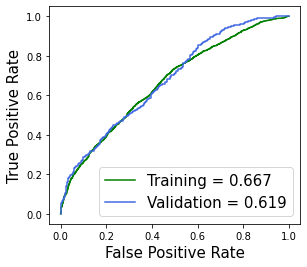

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4.5, 4))

#AUC = roc_auc_score(train_target, train_pred)
plt.plot(fpr_tr, tpr_tr, label="Training = {:.3f}".format(AUC_tr), color='green')
#AUC = roc_auc_score(valid_target, valid_pred)
plt.plot(fpr_va, tpr_va, label="Validation = {:.3f}".format(AUC_va), color='royalblue')
#AUC = roc_auc_score(test_target, test_pred)
#plt.plot(fpr_te, tpr_te, label="TEST = {:.3f}".format(AUC_te))
plt.legend(fontsize=15) 
#lt.title("ROC curve", fontsize=18)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.show()

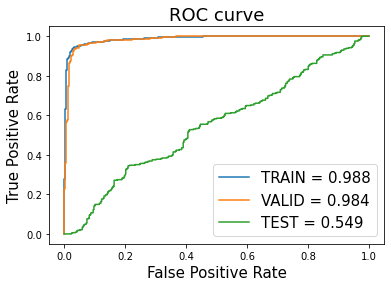

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

#AUC = roc_auc_score(train_target, train_pred)
plt.plot(fpr_tr, tpr_tr, label="TRAIN = {:.3f}".format(AUC_tr))
#AUC = roc_auc_score(valid_target, valid_pred)
plt.plot(fpr_va, tpr_va, label="VALID = {:.3f}".format(AUC_va))
#AUC = roc_auc_score(test_target, test_pred)
plt.plot(fpr_te, tpr_te, label="TEST = {:.3f}".format(AUC_te))
plt.legend(fontsize=15) 
plt.title("ROC curve", fontsize=18)
plt.xlabel("False Positive Rate", fontsize=15)
plt.ylabel("True Positive Rate", fontsize=15)
plt.show()

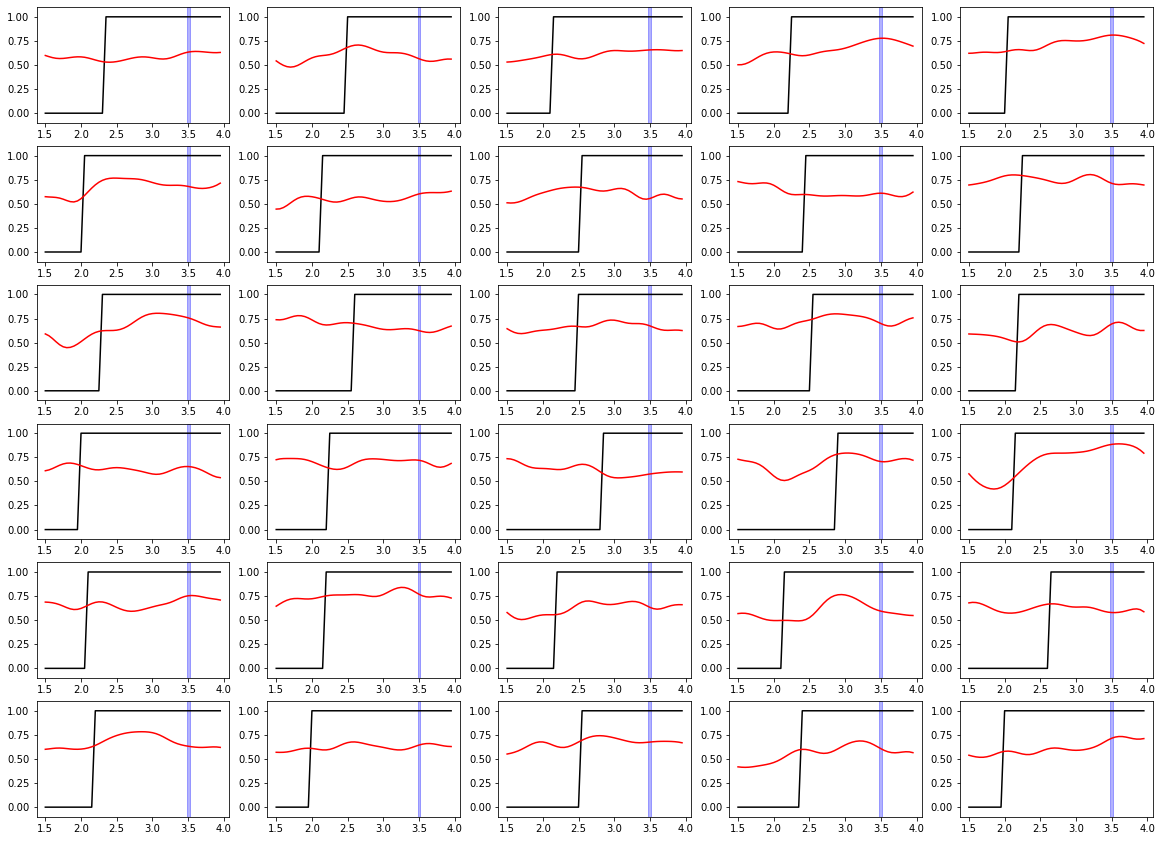

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(valid_target.shape[0]/prediction_frames)):
    plt.subplot(8, 5, ex+1)
    plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, valid_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(3.48, 3.52, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

In [28]:
classified_valid_pred = []
for f in range(valid_pred.shape[0]):
    if valid_pred[f, 0] > all_va_opt_thr[model_number]:
        classified_valid_pred.append(1)
    else:
        classified_valid_pred.append(0)

classified_valid_pred = np.array(classified_valid_pred)
print(classified_valid_pred.shape)

(1500,)


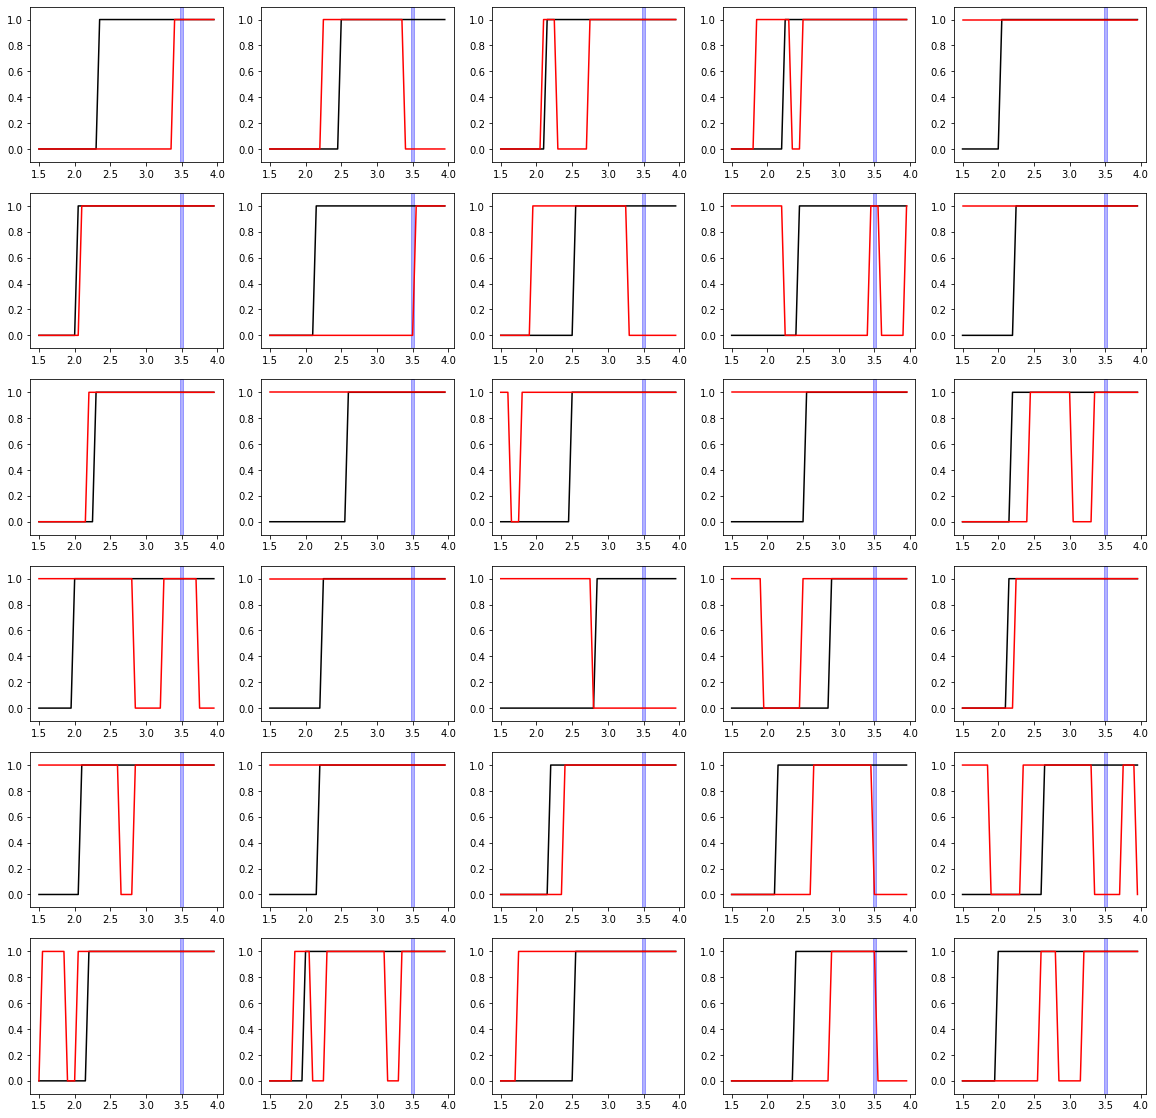

In [29]:
plt.figure(figsize=(20, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(valid_target.shape[0]/prediction_frames)):
    plt.subplot(6, 5, ex+1)
    plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(3.48, 3.52, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

(-0.1, 1.1)

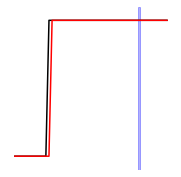

In [30]:
plt.figure(figsize=(3, 3))  # 幅12インチ、高さ8インチのFigureを作成

ex = 5
#plt.subplot(1, 2, ex+1)
plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
plt.axvspan(3.48, 3.52, color='blue', alpha=0.3)
plt.axis('off')
plt.ylim(-0.1, 1.1)

(-0.1, 1.1)

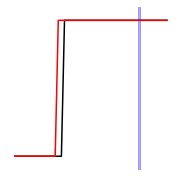

In [31]:
plt.figure(figsize=(3, 3))  # 幅12インチ、高さ8インチのFigureを作成

ex = 10
#plt.subplot(1, 2, ex+1)
plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
plt.axvspan(3.48, 3.52, color='blue', alpha=0.3)
plt.axis('off')
plt.ylim(-0.1, 1.1)

In [ ]:
plt.figure(figsize=(20, 10))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, test_pred[ex*prediction_frames:(ex+1)*prediction_frames, 0], color='red')
    plt.axvspan(4.5, 4.5, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

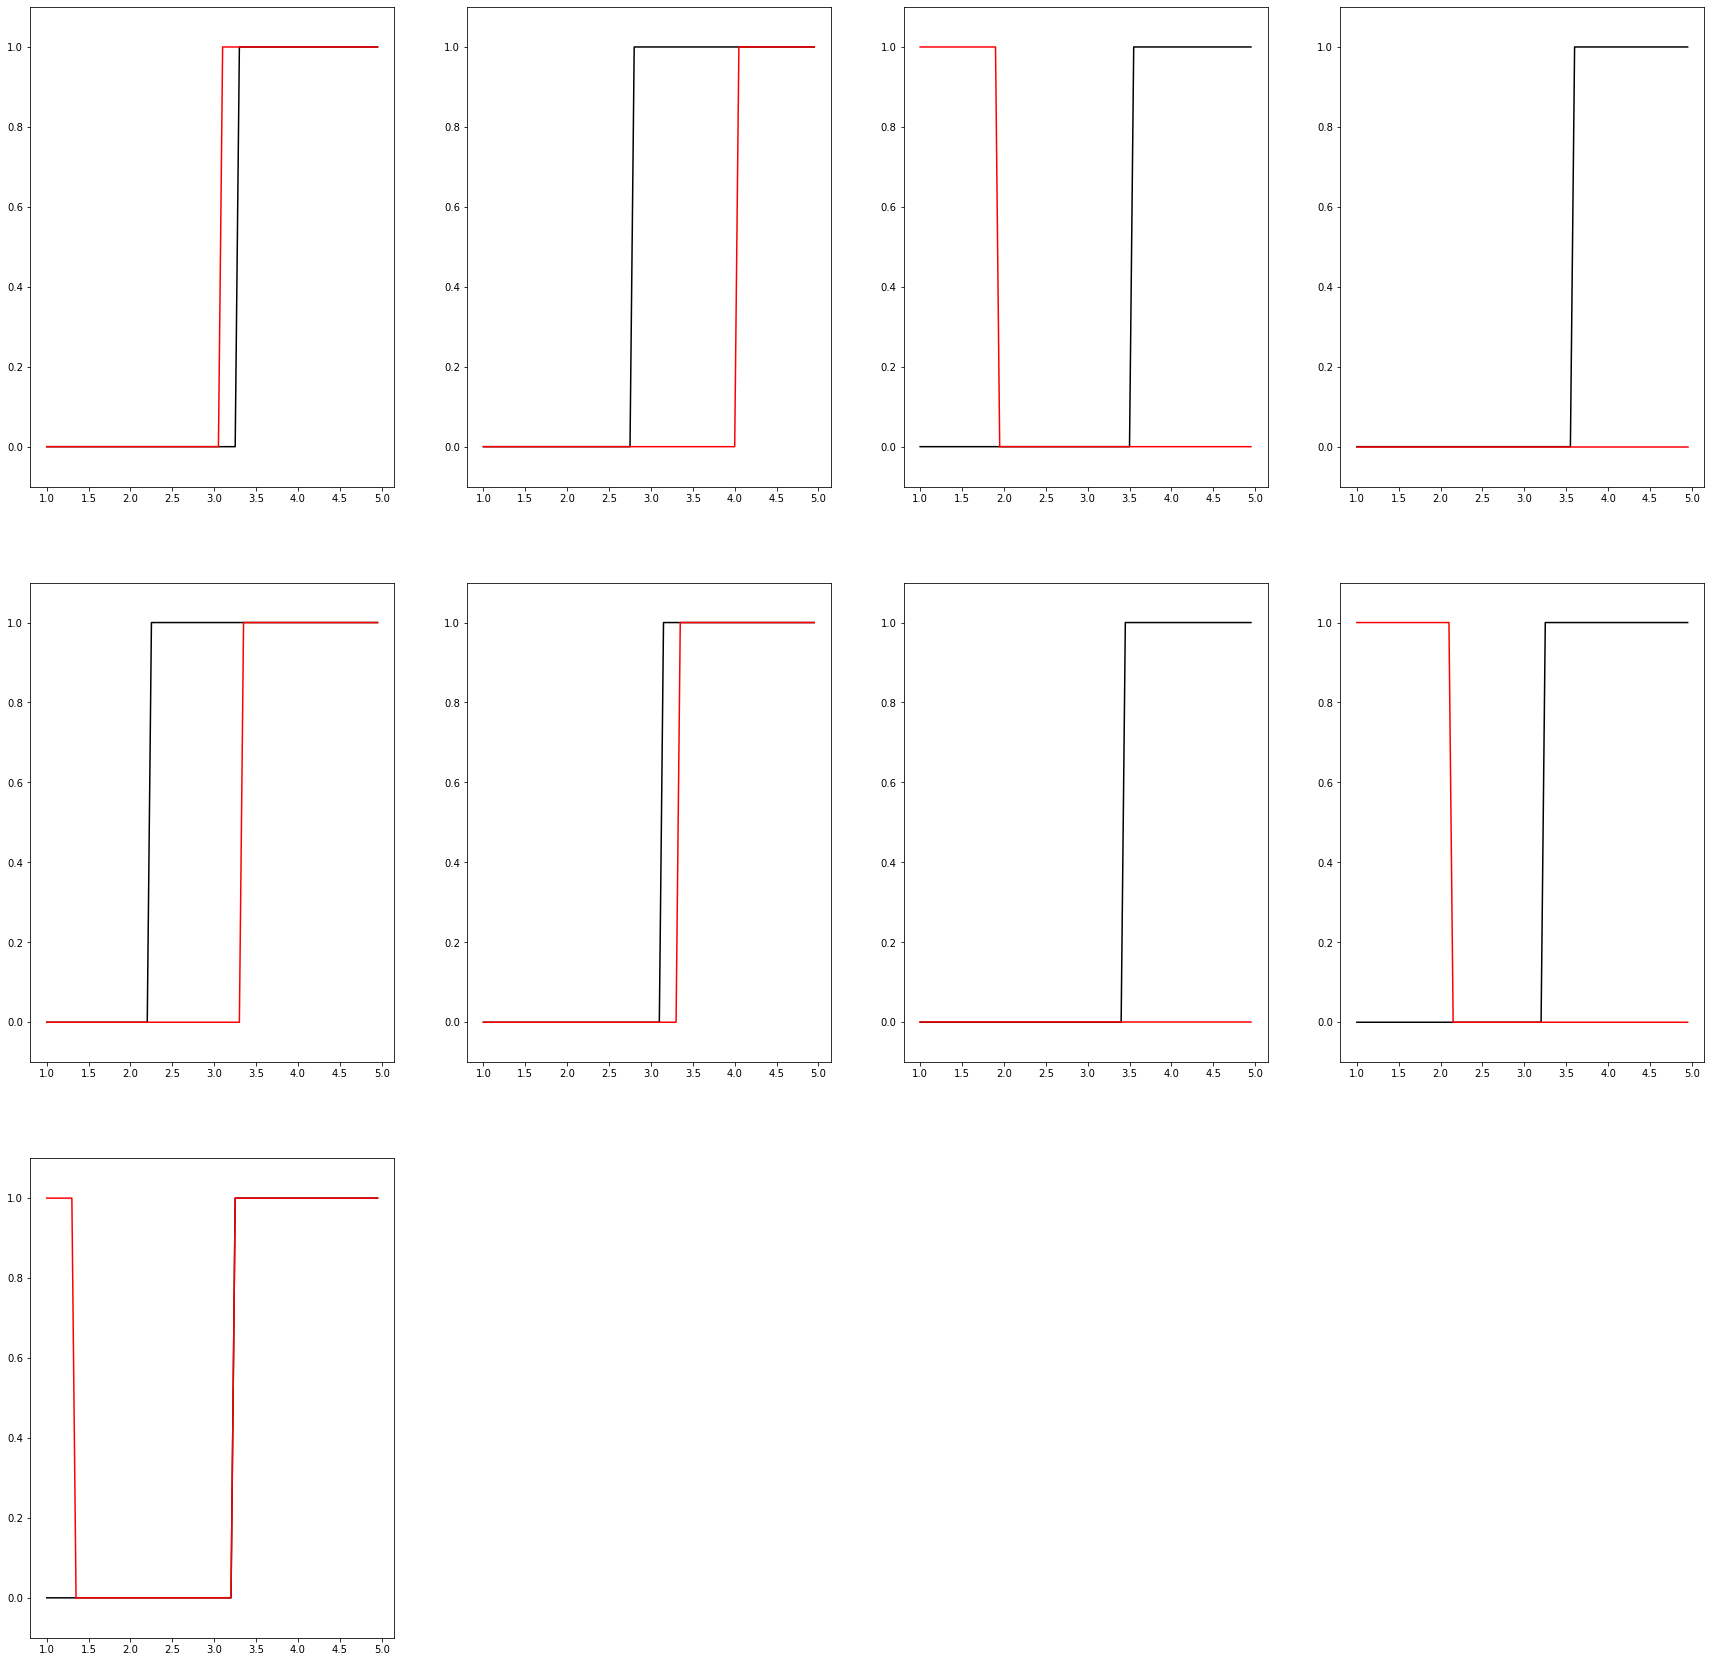

In [18]:
plt.figure(figsize=(30, 30))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(valid_target.shape[0]/prediction_frames)):
    plt.subplot(3, 4, ex+1)
    plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    #plt.axvspan(2.05, 2.05, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

(-0.1, 1.1)

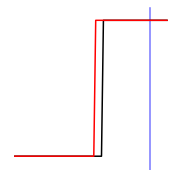

In [19]:
plt.figure(figsize=(3, 3))  # 幅12インチ、高さ8インチのFigureを作成

ex = 0
#plt.subplot(1, 2, ex+1)
plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
plt.axvspan(4.48, 4.52, color='blue', alpha=0.3)
plt.axis('off')
plt.ylim(-0.1, 1.1)

(-0.1, 1.1)

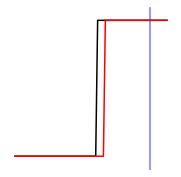

In [20]:
plt.figure(figsize=(3, 3))  # 幅12インチ、高さ8インチのFigureを作成

ex = 5
#plt.subplot(1, 2, ex+1)
plt.plot(t, valid_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
plt.plot(t, classified_valid_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
plt.axvspan(4.48, 4.52, color='blue', alpha=0.3)
plt.axis('off')
plt.ylim(-0.1, 1.1)

In [19]:
shap_number_ss = "SsStim_evoked_multi_09"
model_number_ss = 19

test_target_ss = np.load(f"{rnn_folder}/model_{shap_number_ss}/model_{model_number_ss}/{date}_{shap_number_ss}_test_targets.npy")
input_test_ss = np.load(f"{rnn_folder}/model_{shap_number_ss}/model_{model_number_ss}/{date}_{shap_number_ss}_test_features.npy")
test_pred_ss = model.predict(input_test_ss)

print(test_target_ss.shape, test_pred_ss.shape)

(231,) (231, 1)


In [20]:
shap_number_vis = "VisStim_evoked_multi_08"
model_number_vis = 5

test_target_vis = np.load(f"{rnn_folder}/model_{shap_number_vis}/model_{model_number_vis}/{date}_{shap_number_vis}_test_targets.npy")
input_test_vis = np.load(f"{rnn_folder}/model_{shap_number_vis}/model_{model_number_vis}/{date}_{shap_number_vis}_test_features.npy")
test_pred_vis = model.predict(input_test_vis)

print(test_target_vis.shape, test_pred_vis.shape)

(231,) (231, 1)


In [21]:
test_target = np.concatenate((test_target_ss, test_target_vis), axis=0)
test_pred   = np.concatenate((test_pred_ss, test_pred_vis), axis=0)

print(test_target.shape)
print(test_pred.shape)

(462,)
(462, 1)


In [28]:
opt_thr_te = all_te_opt_thr[model_number]

ex_classified_test_pred = []
for f in range(test_pred.shape[0]):
    if test_pred[f, 0] > opt_thr_te:
        ex_classified_test_pred.append(1)
    else:
        ex_classified_test_pred.append(0)

ex_classified_test_pred = np.array(ex_classified_test_pred)
print(ex_classified_test_pred.shape)

(462,)


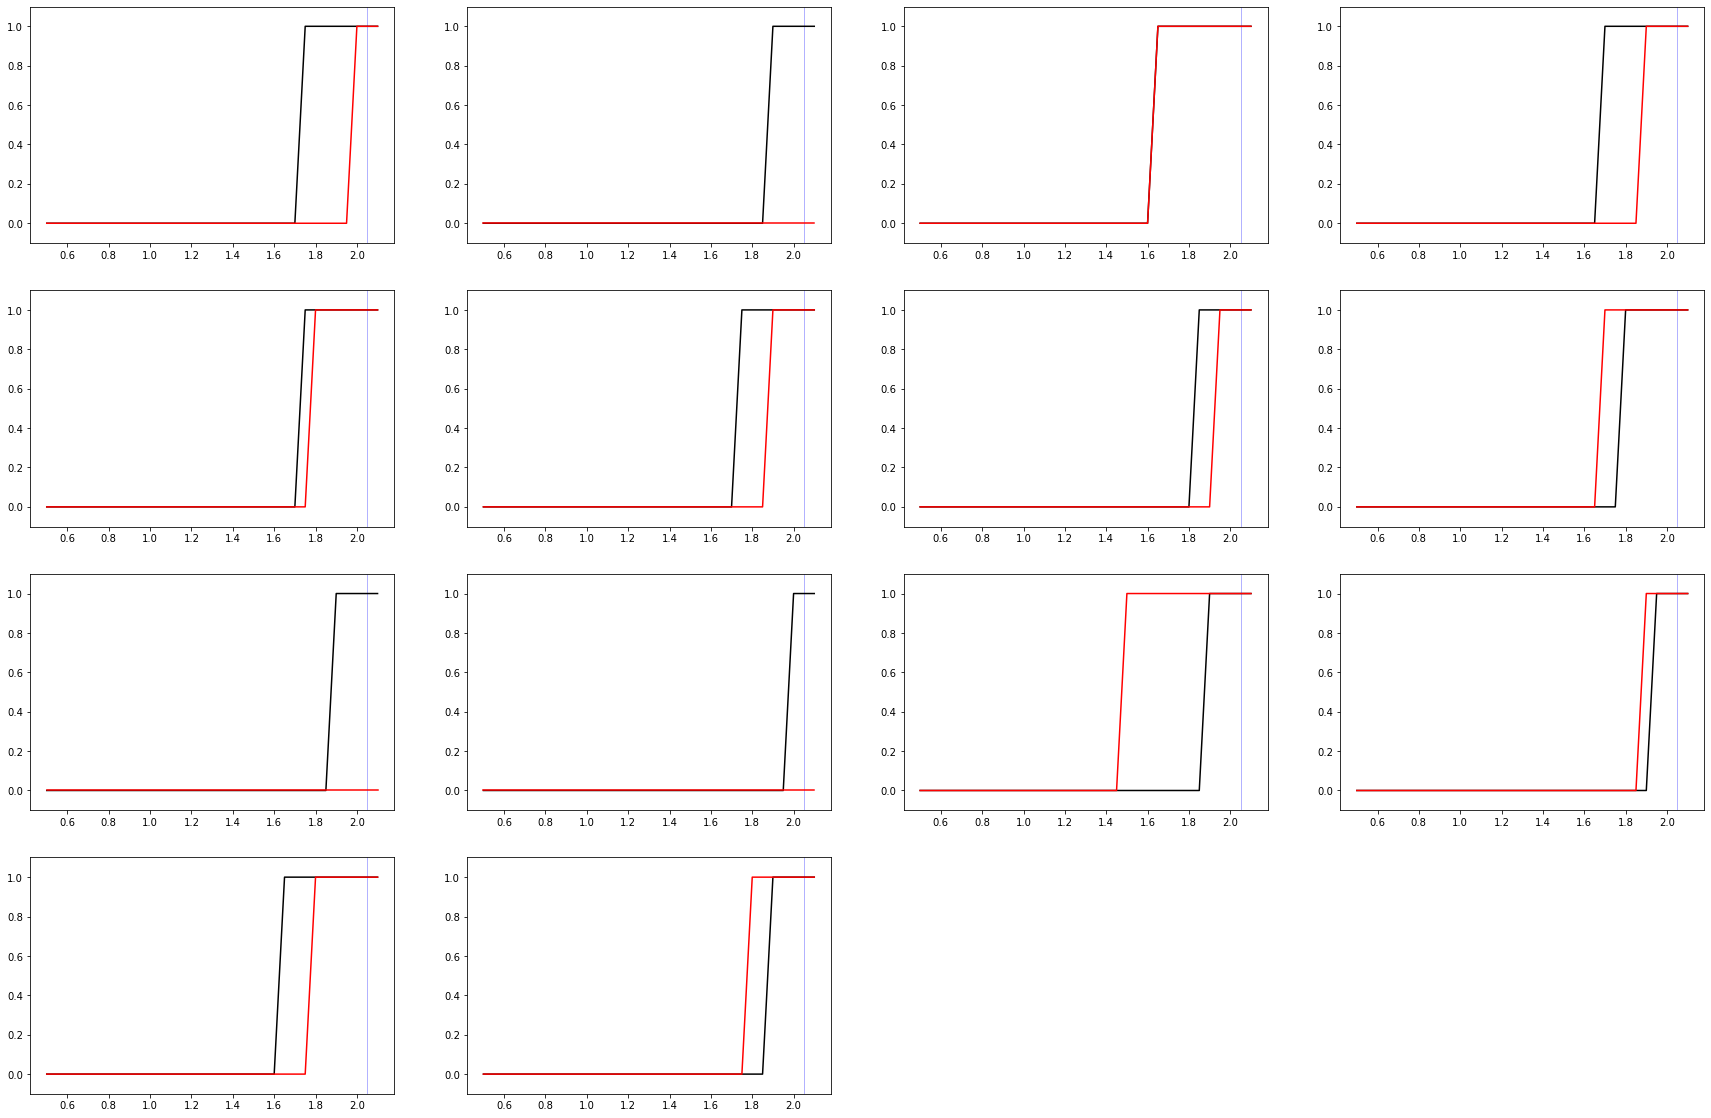

In [30]:
plt.figure(figsize=(30, 20))  # 幅12インチ、高さ8インチのFigureを作成

for ex in range(int(test_target.shape[0]/prediction_frames)):
    plt.subplot(4, 4, ex+1)
    plt.plot(t, test_target[ex*prediction_frames:(ex+1)*prediction_frames], color='black')
    plt.plot(t, ex_classified_test_pred[ex*prediction_frames:(ex+1)*prediction_frames], color='red')
    plt.axvspan(2.05, 2.05, color='blue', alpha=0.3)
    plt.ylim(-0.1, 1.1)
    
plt.show()

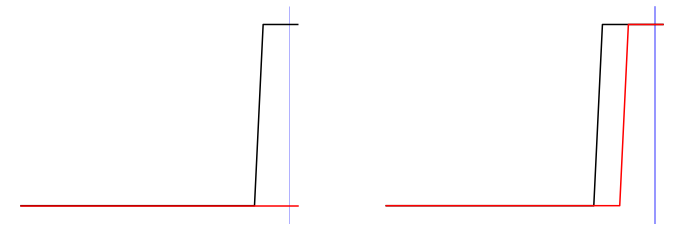

In [32]:
plt.figure(figsize=(12, 4))  # 幅12インチ、高さ8インチのFigureを作成

ex_list = [1, 5]
ex_classified = [ex_classified_test_pred[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], ex_classified_test_pred[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]
ex_target = [test_target[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], test_target[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]

for ex in range(len(ex_list)):
    plt.subplot(1, 2, ex+1)
    plt.plot(t, ex_target[ex], color='black')
    plt.plot(t, ex_classified[ex], color='red')
    plt.axvspan(2.048, 2.052, color='blue', alpha=0.3)
    plt.axis('off')
    plt.ylim(-0.1, 1.1)

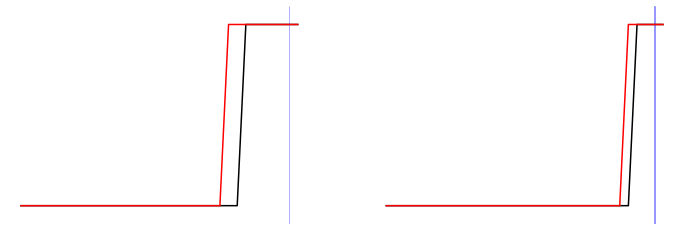

In [34]:
plt.figure(figsize=(12, 4))  # 幅12インチ、高さ8インチのFigureを作成

ex_list = [7, 11]
ex_classified = [ex_classified_test_pred[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], ex_classified_test_pred[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]
ex_target = [test_target[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], test_target[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]

for ex in range(len(ex_list)):
    plt.subplot(1, 2, ex+1)
    plt.plot(t, ex_target[ex], color='black')
    plt.plot(t, ex_classified[ex], color='red')
    plt.axvspan(2.048, 2.052, color='blue', alpha=0.3)
    plt.axis('off')
    plt.ylim(-0.1, 1.1)

plt.show()

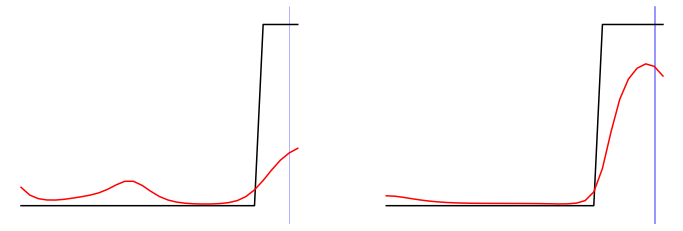

In [22]:
plt.figure(figsize=(12, 4))  # 幅12インチ、高さ8インチのFigureを作成

ex_list = [1, 5]
ex_classified = [test_pred[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], test_pred[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]
ex_target = [test_target[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], test_target[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]

for ex in range(len(ex_list)):
    plt.subplot(1, 2, ex+1)
    plt.plot(t, ex_target[ex], color='black')
    plt.plot(t, ex_classified[ex], color='red')
    plt.axvspan(2.048, 2.052, color='blue', alpha=0.3)
    plt.axis('off')
    plt.ylim(-0.1, 1.1)

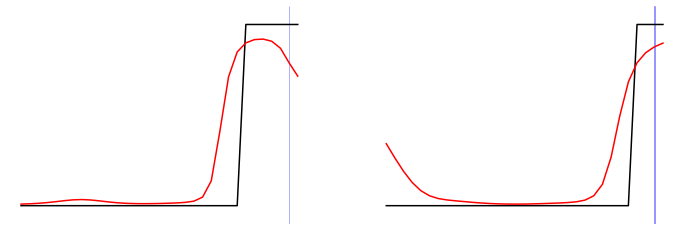

In [23]:
plt.figure(figsize=(12, 4))  # 幅12インチ、高さ8インチのFigureを作成

ex_list = [7, 11]
ex_classified = [test_pred[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], test_pred[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]
ex_target = [test_target[ex_list[0]*prediction_frames:(ex_list[0]+1)*prediction_frames], test_target[ex_list[1]*prediction_frames:(ex_list[1]+1)*prediction_frames]]

for ex in range(len(ex_list)):
    plt.subplot(1, 2, ex+1)
    plt.plot(t, ex_target[ex], color='black')
    plt.plot(t, ex_classified[ex], color='red')
    plt.axvspan(2.048, 2.052, color='blue', alpha=0.3)
    plt.axis('off')
    plt.ylim(-0.1, 1.1)